#  Email Spam Detection with Machine Learning

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
import re
import string

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

# Load NTLK Files

In [5]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [6]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Load Datasets

In [7]:
df=pd.read_csv("spam.csv", encoding='latin1')

In [8]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


#### Take Only Requied Columns

In [9]:
df=df[['v1','v2']]

In [10]:
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


#### Rename Columns' Name

In [11]:
df.columns=[["Label","Message"]]

In [12]:
df

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


# Basic Information

In [13]:
# view sample data
df.sample(5)

,Label,Message
4218,ham,Anything lor if they all go then i go lor...
3451,ham,Ugh just got outta class
5104,ham,A Boy loved a gal. He propsd bt she didnt mind...
4442,ham,You know my old Dom I told you about yesterday...
2153,ham,I dont have i shall buy one dear


In [14]:
# show information of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   (Label,)    5572 non-null   object
 1   (Message,)  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [15]:
# show statistical data
df.describe()

,Label,Message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [16]:
# (rows,columns)
df.shape

(5572, 2)

# Check Missing Values

In [17]:
df.isnull().sum()   # No Missing Value

,0
Label,0
Message,0


# Check Duplicate Values

In [18]:
df.duplicated().sum()

np.int64(403)

There are 403 duplicate values

In [19]:
df=df.drop_duplicates()   #remove duplicate values

# Class Distribution

#### Count

In [20]:
df["Label"].value_counts()

,count
"(Label,)",
ham,4516
spam,653


#### Percentage

In [21]:
((df["Label"].value_counts())/df.shape[0])*100

,count
"(Label,)",
ham,87.366996
spam,12.633004


In [22]:
percentage=((df["Label"].value_counts())/df.shape[0])*100

In [23]:
percentage

,count
"(Label,)",
ham,87.366996
spam,12.633004


#### Visualization

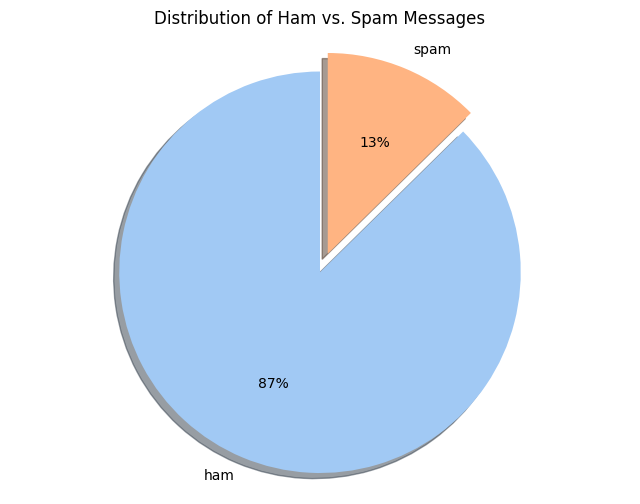

In [24]:
plt.figure(figsize=(8,6))
explode = [0, 0.1] # To slightly separate the 'spam' slice
plt.pie(percentage, labels=["ham","spam"], colors = sns.color_palette('pastel')[0:len(percentage)],
        autopct='%.0f%%', shadow=True, startangle=90, explode=explode)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Distribution of Ham vs. Spam Messages')
plt.show()

# Text Preprocessing

In [25]:
# create stemmer
stemmer=PorterStemmer()
stop_words=set(stopwords.words('english'))

In [26]:
# cleaning function
from nltk.sem.relextract import re
def clean_text(text):
  text=text.lower()
  text=re.sub(r"http\S+","",text)
  text=re.sub(r"\d+","",text)
  text=text.translate(str.maketrans("","",string.punctuation))

  words=text.split()

  words=[
      stemmer.stem(word)
      for word in words
      if word not in stop_words
  ]
  return  " ".join(words)

In [27]:
df

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [28]:
df.loc[:, ('clean_message',)] = df[('Message',)].apply(clean_text)

/tmp/ipykernel_16220/3599867246.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, ('clean_message',)] = df[('Message',)].apply(clean_text)


In [29]:
df

,Label,Message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,nd time tri contact u u å£ pound prize claim e...
5568,ham,Will Ì_ b going to esplanade fr home?,ì b go esplanad fr home
5569,ham,"Pity, * was in mood for that. So...any other s...",piti mood soani suggest
5570,ham,The guy did some bitching but I acted like i'd...,guy bitch act like id interest buy someth els ...


# Convert Labels

In [30]:
df["Label",]=df["Label",].map({
    "ham":0,
    "spam":1,
})

/tmp/ipykernel_16220/1969862126.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Label",]=df["Label",].map({


In [31]:
df.head(10)

,Label,Message,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,0,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though
5,1,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darl week word back id like fun st...
6,0,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,0,As per your request 'Melle Melle (Oru Minnamin...,per request mell mell oru minnaminungint nurun...
8,1,WINNER!! As a valued network customer you have...,winner valu network custom select receivea å£ ...
9,1,Had your mobile 11 months or more? U R entitle...,mobil month u r entitl updat latest colour mob...


# Train/Test Split

In [32]:
x=df["clean_message"]
y=df["Label"]

In [33]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [34]:
x_train.shape

(4135, 1)

In [35]:
x_test.shape

(1034, 1)

In [36]:
print("Training Samples :",len(x_train))

Training Samples : 4135


In [37]:
print("Testing Samples : ",len(x_test))

Testing Samples :  1034


# TF-IDF Feature Extraction

In [38]:
tfidf=TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

In [39]:
x_train_tfidf=tfidf.fit_transform(x_train.iloc[:, 0])
x_test_tfidf=tfidf.fit_transform(x_test.iloc[:, 0])

In [40]:
print("Training TF-IDF shape:",x_train_tfidf.shape)

Training TF-IDF shape: (4135, 5000)


In [41]:
print("Training TF-IDF shape:",x_test_tfidf.shape)

Training TF-IDF shape: (1034, 5000)


# **Model 1: Multinomial Naive Bayes**

In [42]:
nb_model=MultinomialNB()

nb_model.fit(x_train_tfidf,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MultinomialNB()

In [43]:
nb_prediction = nb_model.predict(x_test_tfidf)

print("Multinomial Naive Bayes Trained Successfully")

Multinomial Naive Bayes Trained Successfully


# Evaluate Naive Bayes

In [44]:
nb_accuracy=accuracy_score(y_test,nb_prediction)

In [45]:
nb_precision=precision_score(y_test,nb_prediction)

In [46]:
nb_recall=recall_score(y_test,nb_prediction)

In [47]:
nb_f1=f1_score(y_test,nb_prediction)

In [48]:
print("Multinomial Naive Bayes Results")
print("--------------------------------")
print(f"Accuracy : {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall   : {nb_recall:.4f}")
print(f"F1-Score : {nb_f1:.4f}")


Multinomial Naive Bayes Results
--------------------------------
Accuracy : 0.8462
Precision: 0.3056
Recall   : 0.1679
F1-Score : 0.2167


# Naive Bayes Classification Report

In [49]:
print(classification_report(
    y_test,nb_prediction,
    target_names=["Ham","Spam"]
))

              precision    recall  f1-score   support

         Ham       0.89      0.94      0.91       903
        Spam       0.31      0.17      0.22       131

    accuracy                           0.85      1034
   macro avg       0.60      0.56      0.57      1034
weighted avg       0.81      0.85      0.83      1034



# Naive Bayes Confusion Matrix

In [50]:
cm_nb=confusion_matrix(y_test,nb_prediction)

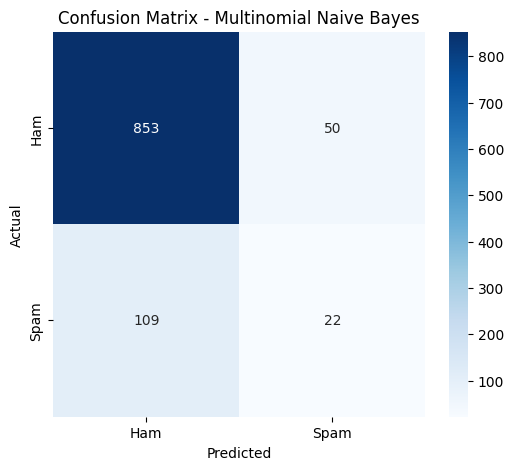

In [51]:
plt.figure(figsize=(6,5))

sns.heatmap(cm_nb,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Ham","Spam"],
            yticklabels=["Ham","Spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.show()

# **Model 2: Logistic Regression**

In [52]:
lr_model=LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [53]:
lr_model.fit(x_train_tfidf,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(max_iter=1000, random_state=42)

In [54]:
lr_predictions=lr_model.predict(x_test_tfidf)
print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


# Evaluate Logistic Regression

In [55]:
lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions)
lr_recall = recall_score(y_test, lr_predictions)
lr_f1 = f1_score(y_test, lr_predictions)

print("Logistic Regression Results")
print("--------------------------")
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-Score : {lr_f1:.4f}")

Logistic Regression Results
--------------------------
Accuracy : 0.8733
Precision: 0.0000
Recall   : 0.0000
F1-Score : 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Logistic Regression Classification Report

In [56]:
print(classification_report(
    y_test,
    lr_predictions,
    target_names=["Ham","Spam"]
))

              precision    recall  f1-score   support

         Ham       0.87      1.00      0.93       903
        Spam       0.00      0.00      0.00       131

    accuracy                           0.87      1034
   macro avg       0.44      0.50      0.47      1034
weighted avg       0.76      0.87      0.81      1034



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Logistic Regression Confusion Matrix

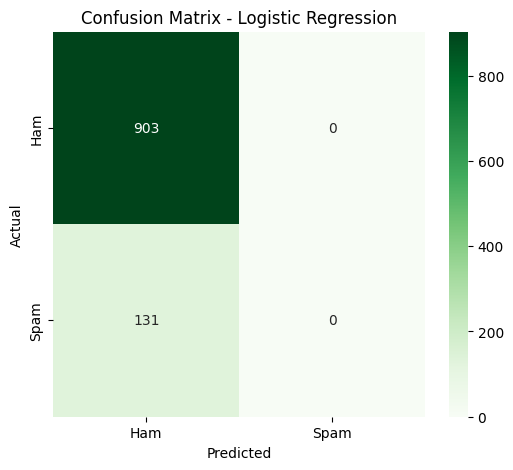

In [57]:
cm_lr = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# **Compare Both Models**

In [60]:
result=pd.DataFrame({
    "Model":[ "Multinomial Naive Bayes",
        "Logistic Regression"],
    "Accuracy":[nb_accuracy,lr_accuracy],
    "Precision":[nb_precision,lr_precision],
    "Recall":[nb_recall,lr_recall],
    "F1-Score":[nb_f1,lr_f1]
})

In [61]:
result

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.846228,0.305556,0.167939,0.216749
1,Logistic Regression,0.873308,0.000000,0.000000,0.000000


# **Visual Model Comparison**

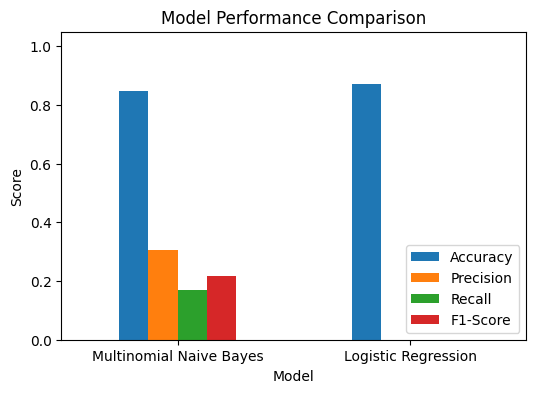

In [63]:
result_plot=result.set_index("Model")

result_plot.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

## Why is Recall Particularly Important for Spam Detection?

Recall measures how many of the actual spam messages are correctly
identified by the model.

In spam detection, a **false negative** occurs when a spam message is
incorrectly classified as a legitimate message.

High recall is important because we want to identify as many actual
spam messages as possible. If recall is low, many spam messages may
reach the user's inbox.

However, precision is also important because incorrectly classifying
legitimate messages as spam can cause important emails to be missed.

Therefore, a good spam detection system should maintain a strong
balance between **precision and recall**, which is represented by the
**F1-score**.